# Datenvisualisierung mit Python/MatPlotLib: 1D, 2D und 3D

Beispiel: Simulation der Brownschen Bewegung in einer, zwei und drei Dimensionen. Die Zeitachse ist als weitere Dimension auch immer Teil der Visualisierung.

Die benötigten Module **NumPy** und **MatPlotLib** sind in den meisten Standardinstallation schon dabei; das Modul **SciPy** muss zusätzlich installiert werden. Installieren von SciPy mit Anaconda (im Anaconda Prompt (Windows) oder Terminal (Linux oder MacOS):

    conda install scipy


#### Module importieren

In [1]:
#NumPy importieren
import numpy as np

In [2]:
# MatPlotLib importieren
import matplotlib.pyplot as plt

In [3]:
# SciPy: benötigte Funktionen importieren
from scipy.stats import norm

## Brownsche Bewegung simulieren: Grundlagen

Brownsche Bewegung: Erklärung bei Wolfram Alpha: 
https://www.wolframalpha.com/input?i=Brownian+motion

Link zum SciPy Cookbook:
https://scipy-cookbook.readthedocs.io/items/BrownianMotion.html

Von Scipy wird die Funktion scipy.stats.norm() benötigt: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
Damit können normalverteilte Zufallszahlen generiert werden.

Die Daten können effizienter erzeugt werden wenn die SciPy-Funktion nur einmal pro Simulation aufgerufen wird. Dazu wird die Funktion brownian(x0, n, dt, delta, out=None) definiert. Parameter der Funktion:
    
    x0 = Anfangsposition
    n = Anzahl Schritte
    dt = Zeitschritt
    delta = Parameter für die Geschwindigkeit der Brownschen Bewegung
    out = Output-Array (wird generiert falls nicht anders spezifiziert)

In [4]:
# Funktion zur Berechnung der Brownschen Bewegung:
def brownian(x0, n, dt, delta, out=None):

    x0 = np.asarray(x0) # Punkte auf der x-Achse

    # Generiere für jedes x0-Element n Zahlen aus einer Normalverteilung
    r = norm.rvs(size=x0.shape + (n,), scale=delta*np.sqrt(dt))

    # Output-Array generieren (falls nicht vorhanden)
    if out is None:
        out = np.empty(r.shape)

    # Brownsche Bewegung wird als kummulative Summe der n sample berechnet
    np.cumsum(r, axis=-1, out=out)

    #  Anfangsbedingung
    out += np.expand_dims(x0, axis=-1)

    return out

## Brownsche Bewegung in 1D

Die Parameter der Simulation werden zuerst definiert.

In [5]:
# Parameter definieren
delta = 0.25 # Paramenter für die Geschwindigkeit der Brownschen Bewegung 
T = 10.0 # Zeit insgesamt
n = 500 # Anzahl Schritte
dt = T/n # Zeitschritt
m = 10 # Anzahl Realisierungen (Trajektorien)

Die Arrays für die Trajektorien werden initialisiert und dann durch Aufrufen der Funktion brownian() berechnet.

In [6]:
# Initialisieren und Trajektorien Berechnen
x = np.empty((m,n+1)) # Array initialisieren
# Anfangsbedingungen für x (Startpunkt)
x[:, 0] = 0.0
# Trajektorien Berechnen
brownian(x[:,0], n, dt, delta, out=x[:,1:])
# Zeitachse erzeugen
t = np.linspace(0.0, n*dt, n+1)

Die m Realisierungen der Brownschen Bewegung können nun visualisiert werden:

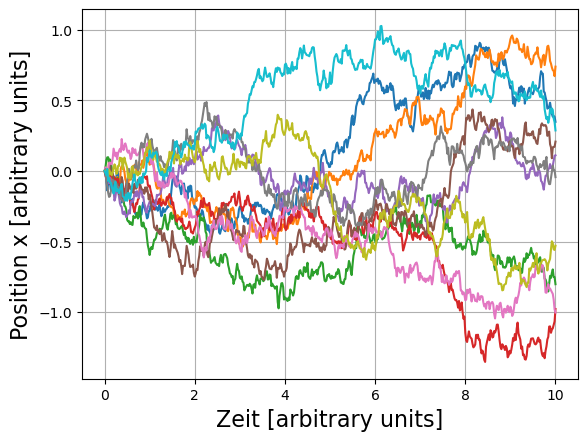

In [7]:
# Trajektorien visualisieren
for k in range(m):
    plt.plot(t, x[k])
plt.xlabel('Zeit [arbitrary units]', fontsize=16)
plt.ylabel('Position x [arbitrary units]', fontsize=16)
plt.grid(True)
plt.savefig('Brownian.png')
plt.show()

## Brownsche Bewegung in 2D

Für die Simulation der Brownschen Bewegung in 2D werden pro Zeitschritt zwei Zufallszahlen (eine für jede Dimension) benötigt.

In [8]:
# Parameter definieren
delta = 0.25 # Paramenter für die Geschwindigkeit der Brownschen Bewegung 
T = 10.0 # Zeit insgesamt
n = 200 # Anzahl Schritte
dt = T/n # Zeitschritt
nD = 2 # Anzahl Dimensionen 

In [9]:
# Initialisierung des arrays
x = np.zeros((nD,n+1))

In [10]:
# Berechnen der Trajektorie
brownian(x[:,0], n, dt, delta, out=x[:,1:])

array([[-1.94770015e-02, -8.74026882e-03, -4.50243075e-03,
        -5.32475564e-02, -1.82559660e-03, -3.27846469e-02,
        -9.90951093e-03, -2.38323899e-02,  8.94779743e-02,
         9.40422923e-02,  4.79001699e-02,  1.06807518e-01,
         5.72040576e-02,  7.91184526e-02, -1.04009070e-02,
        -6.12436521e-02, -4.32024417e-03, -4.65931464e-04,
        -2.97562251e-03, -6.20180823e-03, -8.38705023e-02,
        -6.88544071e-02, -1.22592983e-01, -1.55732949e-01,
        -6.47186779e-02, -5.54536250e-02, -9.99738969e-02,
        -6.65250603e-02, -4.99529153e-02, -7.44540934e-02,
        -1.01491725e-01, -3.72355099e-02, -4.51718736e-02,
        -8.08688195e-02, -3.41465748e-02, -3.16967305e-02,
        -5.83718494e-03, -6.90631790e-03,  1.11850878e-01,
         8.31979248e-02,  1.81763232e-01,  1.15312099e-01,
         1.33845697e-01,  1.27147833e-01,  8.05710522e-02,
         1.40510355e-01,  1.31506944e-01,  1.13392510e-01,
        -2.47667658e-02, -9.50466250e-03,  7.29805671e-0

#### Visualisierung in 2D

Die Visualisierung zeigt die gesamte Trajektorie. Die Zeitdimension ist durch das Markieren der Anfangs und Endpunkte dargestellt.

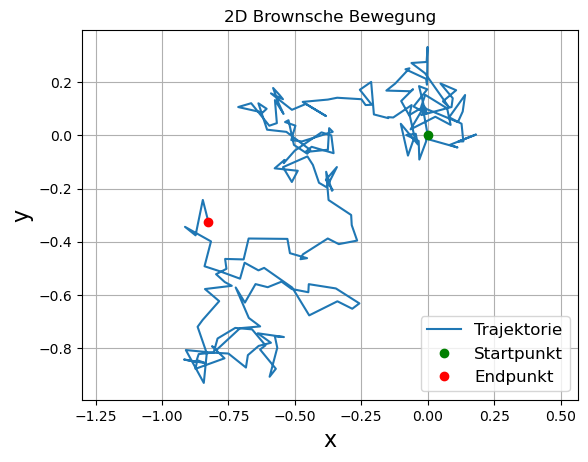

In [11]:
# Plotten der Trajektorie in 2D
plt.plot(x[0],x[1]) 

# Startpunkt und Endpunkt markieren
plt.plot(x[0,0],x[1,0], 'go') # Startpunkt grün
plt.plot(x[0,-1], x[1,-1], 'ro') # Endpunkt rot

# Achsen und Plot beschriften
plt.title('2D Brownsche Bewegung') # Titel
plt.xlabel('x', fontsize=16) # Beschriftung x-Achse
plt.ylabel('y', fontsize=16) # Beschriftung y-Achse
plt.axis('equal')
plt.grid(True) # Grid im Plot anzeigen
plt.legend([ "Trajektorie","Startpunkt","Endpunkt"], fontsize=12) # Datensätze beschriften
plt.show()

## Brownsche Bewegung in 3D

Für die Simulation der Brownschen Bewegung in 3D werden pro Zeitschritt drei Zufallszahlen (eine für jede Dimension) benötigt.

Für das 3D-Plotting werden einige zusätzliche Matplotlib-Funktionen benötigt:

In [12]:
from pylab import rcParams
from mpl_toolkits.mplot3d.axes3d import Axes3D

In [13]:
# Parameter definieren
delta = 0.25 # Paramenter für die Geschwindigkeit der Brownschen Bewegung 
T = 10.0 # Zeit insgesamt
n = 100 # Anzahl Schritte
dt = T/n # Zeitschritt
nD = 3 # Anzahl Dimensionen 

In [14]:
# Initialisierung des arrays
x = np.zeros((nD,n+1))

In [15]:
# Berechnen der trajektorie
brownian(x[:,0], n, dt, delta, out=x[:,1:])
x.shape
x[0]

array([ 0.        ,  0.02584457,  0.07272295,  0.05887849, -0.0050307 ,
        0.14518297,  0.13003675,  0.14122037,  0.18040847,  0.19697961,
        0.11849848,  0.12396494,  0.13645958,  0.19434444,  0.11907249,
        0.01010355,  0.18814042,  0.04753139,  0.06160578,  0.15911922,
        0.27249302,  0.3028403 ,  0.23823384,  0.25545178,  0.35522608,
        0.28565742,  0.28505984,  0.22697592,  0.22197988,  0.08181094,
        0.07716169,  0.08161598,  0.03470459, -0.07912486, -0.14832391,
       -0.11709081, -0.15837781, -0.12309663, -0.03515642, -0.15804174,
       -0.20489972, -0.2271607 , -0.12784607, -0.09668988,  0.00939159,
        0.02507316,  0.03752103,  0.10067579,  0.08335304,  0.07713468,
        0.10766312,  0.1463877 ,  0.2228188 ,  0.19597317,  0.17570624,
        0.00241709,  0.04952714,  0.17916932,  0.01267066,  0.11818544,
        0.24088173,  0.11201385,  0.30355273,  0.27782832,  0.23776624,
        0.12810765, -0.04592861,  0.07129845,  0.09028421,  0.02

#### Visualisierung der Brownschen Bewegung in 3D

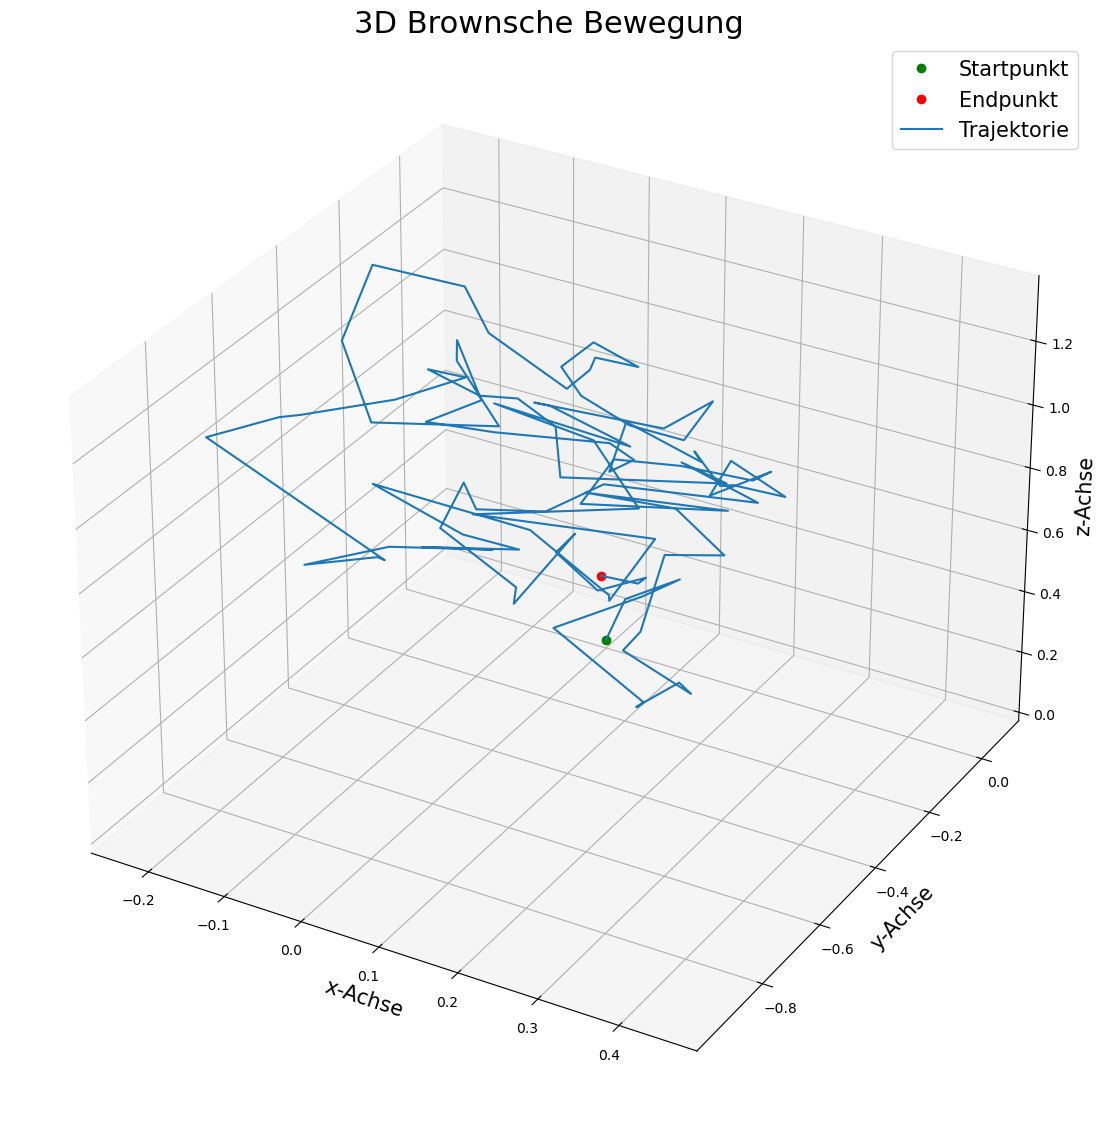

In [16]:
rcParams['figure.figsize'] = 14, 14 # Grösse des Plots
plt.rcParams.update({'font.size': 10}) # Grösse der Beschriftung

ax = plt.figure().add_subplot(projection='3d') # 3D Plot initialisieren
xdata, ydata, zdata = x[:3,:] # Simulationsdaten in 3 Dimensionen aufteilen

# Startpunkt und Endpunkt markieren
ax.plot(xdata[0], ydata[0], zdata[0],'go') # Startpunkt grün
ax.plot(xdata[n], ydata[n], zdata[n], 'ro') # Endpunkt rot

ax.set_xlabel('x-Achse', fontsize=15) # Label x-Achse
ax.set_ylabel('y-Achse', fontsize=15) # Label y-Achse
ax.set_zlabel("z-Achse", fontsize=15, rotation=90) # Label z-Achse

ax.plot3D(xdata, ydata, zdata) # Daten plotten
ax.set_title('3D Brownsche Bewegung', fontsize=22) # Titel des Plots

ax.legend(["Startpunkt","Endpunkt", "Trajektorie"], fontsize=15) # Beschrifgung der Daten

plt.show()